In [7]:
# ===== 数据加载 =====
# 输入文件:
# /mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3
# /mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.asm.ch.fa

import pandas as pd
import numpy as np

GFF = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3"

# 只读前几列，加快解析
gff = pd.read_csv(GFF, sep="\t", comment="#", header=None, usecols=[0, 2, 3, 4, 6],
                  names=["chr", "feature", "start", "end", "strand"])

# 只保留 gene 级特征（1-based 坐标）
genes = gff[gff["feature"] == "gene"].copy()
genes["length"] = genes["end"] - genes["start"] + 1

print(f"基因总数: {len(genes)}")
print(genes[["chr", "start", "end", "strand", "length"]].head())

基因总数: 55986
      chr  start    end strand  length
0    Chr1   2903  10817      +    7915
54   Chr1  11218  12435      +    1218
62   Chr1  12648  15915      +    3268
76   Chr1  16292  20323      +    4032
141  Chr1  22841  26971      +    4131


In [8]:
# ===== 配置 =====
BIN_WIDTH = 250   # 分箱宽度 (bp)，1kb = 1000 bp
TOP_N = 50         # 绘图时展示前 TOP_N 个高频区间

In [9]:
# 以 BIN_WIDTH 为宽度分箱，上限取到最大长度的下一个整箱
max_len = genes["length"].max()
bins = np.arange(0, int(np.ceil(max_len / BIN_WIDTH)) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
labels = [f"{i / 1000:g}-{(i + BIN_WIDTH) / 1000:g}kb" for i in bins[:-1]]

genes["bin"] = pd.cut(genes["length"], bins=bins, labels=labels, right=True)

# 频数表（含累计占比）
freq = genes["bin"].value_counts().sort_index().reset_index()
freq.columns = ["length_range", "count"]
freq["ratio_pct"] = (freq["count"] / len(genes) * 100).round(3)
freq["cum_ratio_pct"] = freq["ratio_pct"].cumsum().round(3)
freq.head()

,length_range,count,ratio_pct,cum_ratio_pct
0,0-0.25kb,655,1.170,1.170
1,0.25-0.5kb,4420,7.895,9.065
2,0.5-0.75kb,4100,7.323,16.388
3,0.75-1kb,3645,6.511,22.899
4,1-1.25kb,3250,5.805,28.704


In [10]:
max_len

np.int64(57094)

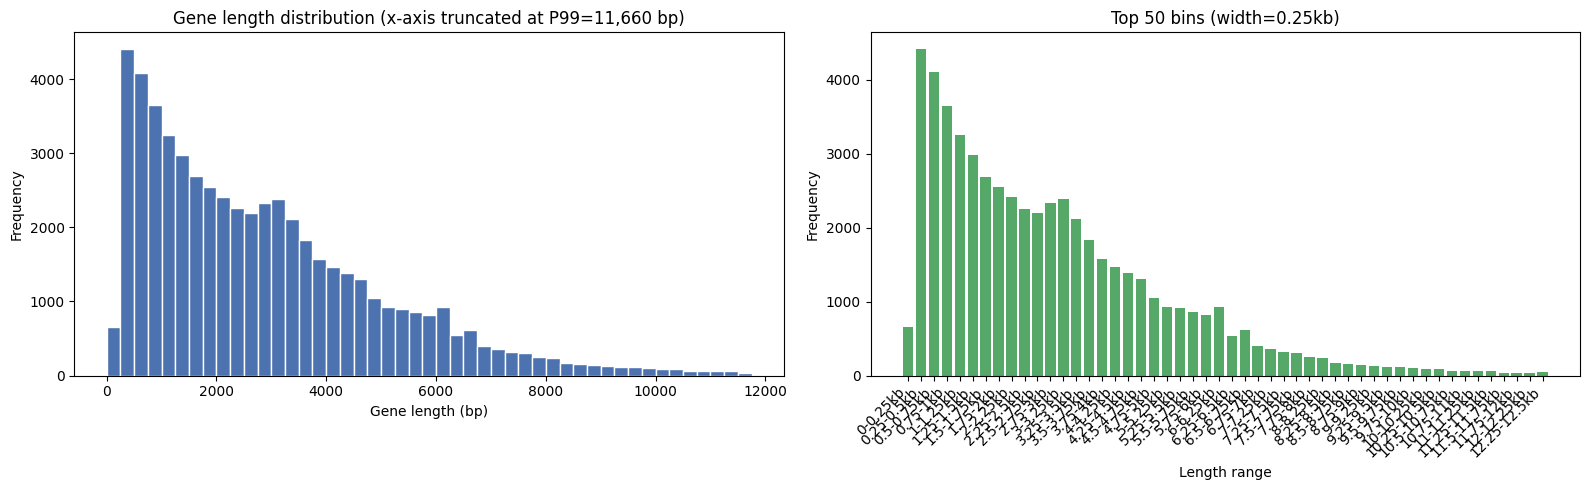

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左: 完整分布（x 轴截断到 99 分位，避免超长基因撑爆图）
p99 = genes["length"].quantile(0.99)
ax = axes[0]
ax.hist(genes["length"], bins=range(0, int(p99) + BIN_WIDTH, BIN_WIDTH),
        color="#4C72B0", edgecolor="white")
ax.set_xlabel("Gene length (bp)"); ax.set_ylabel("Frequency")
ax.set_title(f"Gene length distribution (x-axis truncated at P99={int(p99):,} bp)")

# 右: 前 TOP_N 个区间（长尾之前的主体）
top = freq.head(TOP_N)
ax = axes[1]
ax.bar(top["length_range"], top["count"], color="#55A868")
ax.set_xlabel("Length range"); ax.set_ylabel("Frequency")
ax.set_title(f"Top {TOP_N} bins (width={BIN_WIDTH/1000:g}kb)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()